# Model Output

In [2]:
# packages for data processing
import numpy as np
import pandas as pd
import xarray as xr
from xmitgcm import open_mdsdataset
import gsw as gsw

# packages for plotting
import matplotlib.pyplot as plt
import plotly.graph_objects as go # interactive/3D plotting
import plotly.express as px
import cmocean.cm as cmo # ocean colormaps

# my own plotting functions
from plotting_functions import *

# technical packages
import warnings

## Load Output Data

In [5]:
model_run = "MIZ018"
delta_t = 4 # time step in seconds
output_dir = "../../MITgcm/so_plumes/" + model_run

# surpress the xmitgcm warning about future changes with timedelta
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=FutureWarning)

    # open dataset
    ds = open_mdsdataset(output_dir, prefix = ['Eta', 'U', 'W', 'T', 'V', 'S', 'PH'], delta_t = delta_t, geometry = "cartesian")

## Value Ranges for All Variables

In [7]:
ranges = pd.DataFrame(columns = ["absmin","absmax","mean"], index = ds.keys())

for var in ds.keys():
    ranges.loc[var,"absmin"] = np.min(np.abs(ds[var].values))
    ranges.loc[var,"absmax"] = np.max(np.abs(ds[var].values))
    ranges.loc[var,"mean"] = ds[var].mean().values

ranges

,absmin,absmax,mean
S,34.155224,34.848438,34.29528
T,0.000001,2.000515,-1.4449344
PH,0.131118,53.566628,17.578339
Eta,0.0,0.00033,9.612317e-05
U,0.0,0.312589,0.0395506
W,0.0,0.08823,9.39638e-14
V,0.0,0.094626,-0.002783276


## Center Grid Column

In [6]:
def single_column_time_evol(ds, var:str, center=True, x=None, y=None, time_unit="D", model_run="", ax=None, **kwargs):
    '''
    Plot time evolution of given variable. If center = true, the center column is plotted. Otherwise x and y must be specified.

    Parameters:
        ds: dataset (mitgcm output)
        var: variable to plot
        center: Plot center column?
        x,y: x and y coordinate of column to plot
        time_unit: Time unit for plotting. "D" for day. "h" for hours.
        model_run: Specify if the model run should be displayed in the title.
        ax: Specify, if the plot should be created on a specific pre-created axes. This can be used to make a figure with multiple plots.
    Returns:
        fig, ax
    '''
    
    if center:
        # find dimensions
        Nx = len(ds.XC)
        Ny = len(ds.YC)

        # center cell indizes
        x = int(Nx/2)
        y = int(Ny/2)
    
    # reduce dataset to specific column
    col = ds.isel(XC = x, XG = x, YC = y, YG = y)

    # convert time coordinate from timedelta64[ns] to float64 in given unit
    col["time"] = col.time / np.timedelta64(1, time_unit)

    if ax == None:
        fig, ax = plt.subplots()
    else:
        fig = ax.figure

    # plot hovmöller, mind the transpose (.T)
    pcm = ax.pcolormesh(col["time"], col["Z"], col[var].T, shading = "nearest", **kwargs)

    # labels
    xlabel = "time ["+ time_unit + "]"
    ylabel = ds["Z"].standard_name + " [" + ds["Z"].units +"]"
    cbarlabel = "[" + ds[var].units +"]"
    title = model_run + "\n" + ds[var].long_name

    # set axis labels
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    # make colorbar
    fig.colorbar(pcm, label = cbarlabel)

    # title
    ax.set_title(title)

    return fig, ax

In [7]:
print("Available cmocean colormaps:")
print(cmo.cmapnames)

Available cmocean colormaps:
['thermal', 'haline', 'solar', 'ice', 'gray', 'oxy', 'deep', 'dense', 'algae', 'matter', 'turbid', 'speed', 'amp', 'tempo', 'rain', 'phase', 'topo', 'balance', 'delta', 'curl', 'diff', 'tarn']


Text(0.5, 0.98, 'Model Run MIZtest\n Center Grid Column')

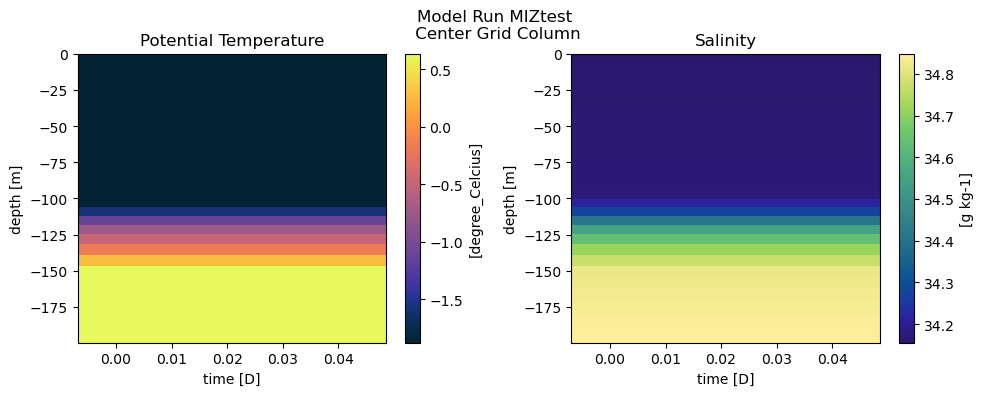

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

single_column_time_evol(ds, "T", ax = axs[0], cmap = cmo.thermal)
single_column_time_evol(ds, "S", ax = axs[1], cmap = cmo.haline)

fig.tight_layout()
fig.suptitle("Model Run " + model_run + "\n Center Grid Column")

## Single Grid Cell Time Evolution

### Temperature

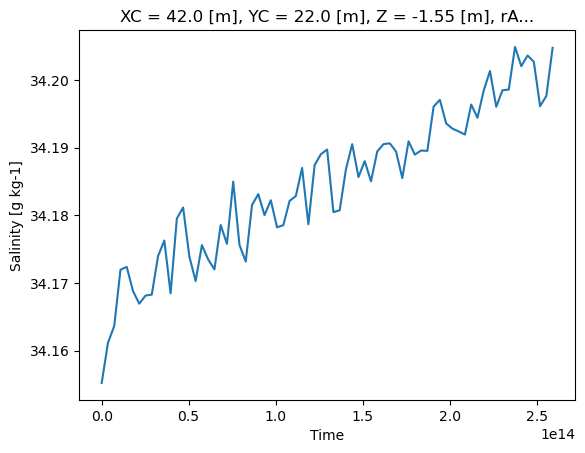

In [9]:
ds["S"].isel(XC = 10, Z =1, YC = 5).plot()


In [10]:
print(ds["T"].min().values)
ds["T"].isel(XC = 8, Z =0, YC = 15).values


-2.0005


array([-1.8616446, -1.8616446, -1.8616446, -1.8616446, -1.8616446,
       -1.8616446, -1.8616446, -1.8616446, -1.8616446, -1.8616446,
       -1.8616446, -1.8616446, -1.8616446, -1.8616446, -1.8616446,
       -1.8616446, -1.8616446, -1.8616446, -1.8616446], dtype=float32)

### Velocities

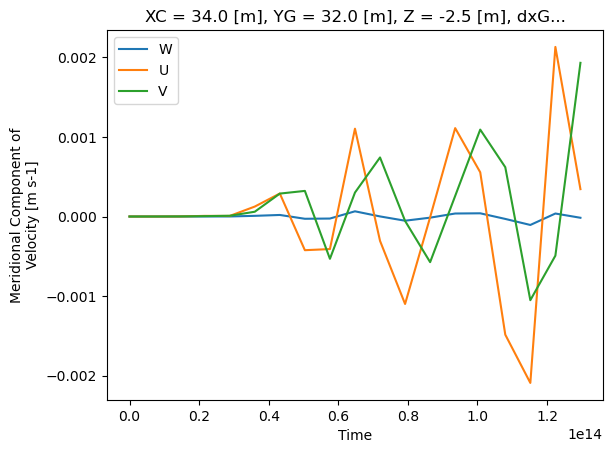

In [5]:
# Velocities
z = 2
x = 8
y = 8

ds["W"].isel(XC = x, Zl =z, YC = y).plot(label = "W")
ds["U"].isel(XG = x, Z =z, YC = y).plot(label = "U")
ds["V"].isel(XC = x, Z =z, YG = y).plot(label = "V")
plt.legend()


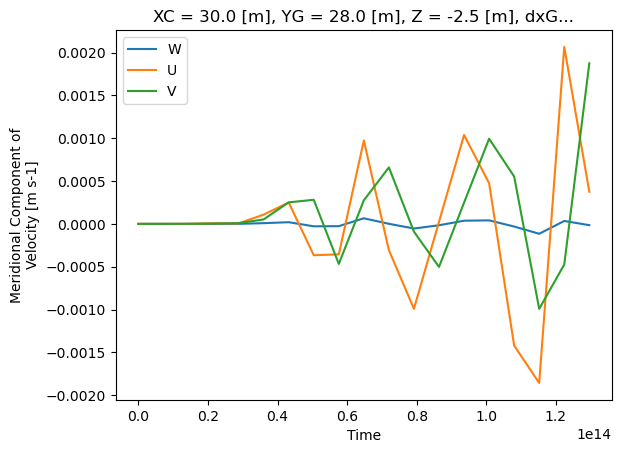

In [6]:
# Velocities
z = 2
x = 7
y = 7

ds["W"].isel(XC = x, Zl =z, YC = y).plot(label = "W")
ds["U"].isel(XG = x, Z =z, YC = y).plot(label = "U")
ds["V"].isel(XC = x, Z =z, YG = y).plot(label = "V")
plt.legend()


In [10]:
print(np.max(np.abs(ds["U"].values)))
print(np.max(np.abs(ds["V"].values)))
print(np.max(np.abs(ds["W"].values)))



0.047425553
0.06906364
0.090963274


## Bird's-eye view

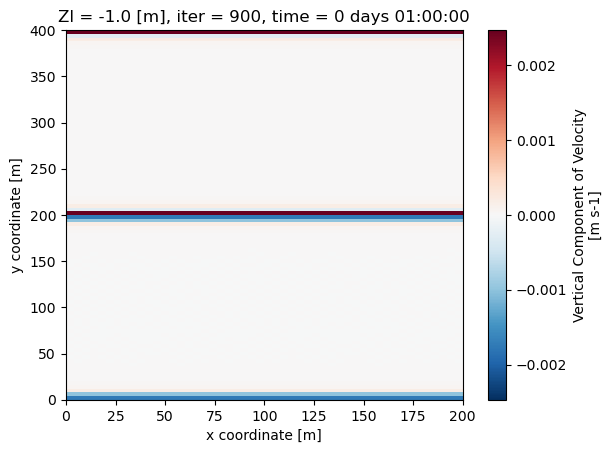

In [11]:
# vertical velocity
ds["W"].isel(time=-1,Zl=1).plot()

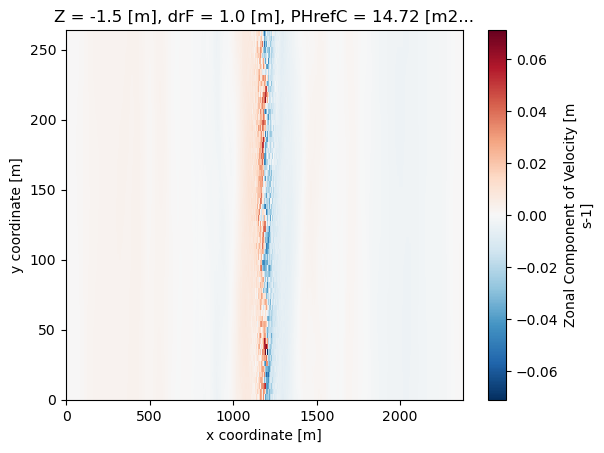

In [8]:
# vertical velocity
ds["U"].isel(time=-1,Z=1).plot()

## 3D Block Time Evolution

### Whole Domain

Plot the whole model domain in a 3D plot with animation to show the temporal evolution (only the faces of the cube are plotted). The animation is opened in a browser window.

Plotly 3D-surface plot examples: https://plotly.com/python/3d-surface-plots/
Plotly Exmaple Animations: https://plotly.com/python/animations/

Documentation: https://plotly.com/python/reference/surface/

In [11]:
# Improvenemts to make:
# - which side is N/S/E/W?
# - convert x/y to lat/lon if possible
# - add other display/save options
# - resolve issue with cube ending on center points of the outermost cells instead of on their edges
# - implement handling of XG, YG, Zl coordinates, so that velocity components can also be plotted

In [6]:
var = "T"
xdim = ds[var].dims[3]
ydim = ds[var].dims[2]
zdim = ds[var].dims[1]

fig=cube_time_evol(ds, var, xdim, ydim, zdim, model_run)
fig.write_html( "animation_" + model_run + "_"+var+ "_wholedomain_" + ".html")
# fig.show(renderer="browser") # works in vscode, not on jupyterhub

#### Velocities

- U: positive eastward
- V: positive northward
- W: positive downward

In [11]:
var = "V"
xdim = ds[var].dims[3]
ydim = ds[var].dims[2]
zdim = ds[var].dims[1]

fig=cube_time_evol(ds, var, xdim, ydim, zdim, model_run)
fig.write_html("animation_" + model_run + "_"+var+"_wholedomain_" + ".html")

### North-South Crossection

In [13]:
half = int(len(ds.XC)/2)

var = "S"
xdim = ds[var].dims[3]
ydim = ds[var].dims[2]
zdim = ds[var].dims[1]

fig = cube_time_evol(ds.isel(XC = slice(0,half)), var, xdim, ydim, zdim, model_run, grid = "False")
fig.write_html( "animation_" + model_run + "_"  + var + "_N-S-crossection" + ".html")

### Quarter Domain

In [31]:
var = "U"
xdim = ds[var].dims[3]
ydim = ds[var].dims[2]
zdim = ds[var].dims[1]

fig = cube_time_evol(ds, var, xdim, ydim, zdim, model_run, colorscale="thermal", quarter=True)
fig.write_html( "animation_" + model_run + "_quarterdomain_" + ".html")
# fig.show(renderer="browser")

### Lead + Vicinity

In [7]:
var = "T"
xdim = ds[var].dims[3]
ydim = ds[var].dims[2]
zdim = ds[var].dims[1]

x_min = 0.0
x_max = 1190.0
mask = (ds["XC"] >= x_min) & (ds["XC"] <= x_max)
ds_sub = ds.where(mask, drop=True)

fig = cube_time_evol(ds_sub, var, xdim, ydim, zdim, model_run, colorscale="thermal", grid=False)

filename = "animation_" + model_run + "_leadview_T" + ".html"
fig.write_html(filename)
# fig.show(renderer="browser")

In [7]:
ds.T.values.min()

np.float32(-1.901)

### To do 

- plot velocity as 3D vector field
- calculate and plot N^2
- visualize (surface) heatflux (from diag)
- calculate & visualized supercooling